<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/CNN/MODEL1.v2Lucas(bayesian_vers)_anna_noBN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Convolutional Neural Networks in PyTorch

This notebook walks through the application of **convolutional neural networks (CNNs)** using PyTorch.

We will study two examples:

1. A **2D CNN for image classification** on the MNIST handwritten digit dataset.
2. A **1D CNN for time-series classification** on a synthetic signal dataset.

The goal is to mirror the ideas from the NumPy implementation, but now using PyTorch's built-in tools:

- `torch.Tensor`
- `torch.nn.Module`
- `torch.nn.Conv2d`
- `torch.nn.Conv1d`
- `torch.nn.ReLU`
- `torch.nn.MaxPool2d`
- `torch.nn.Linear`
- `torch.optim`
- automatic differentiation through `loss.backward()`

PyTorch handles the tedious backpropagation bookkeeping for us, but the mathematical structure is the same as the NumPy version.



## 1. What is a Convolutional Neural Network?

A fully connected neural network treats each input feature as separate. For images, this ignores spatial structure. A CNN instead uses **filters**, also called **kernels**, that slide across an input and detect local patterns.

For a 2D image, a convolutional layer learns filters that may detect edges, corners, curves, or other local image features.

For a 1D time series, a convolutional layer learns filters that may detect spikes, oscillations, trends, or short temporal patterns.

A typical CNN layer sequence is:

\[
\text{Input} \rightarrow \text{Convolution} \rightarrow \text{Activation} \rightarrow \text{Pooling} \rightarrow \text{Dense Layers} \rightarrow \text{Prediction}.
\]

In PyTorch, these operations are represented as neural network layers.



## 2. Imports and Reproducibility

We will use PyTorch for neural network layers and training, NumPy for data generation, and Matplotlib for visualization.


In [1]:
# in a setup cell
!pip install blitz-bayesian-pytorch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 1.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt

import sympy
import sympy.core          # force submodule onto the namespace
import sympy.core.symbol
import torch               # now import torch

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

import importlib
sympy.core = importlib.import_module("sympy.core")
sympy.core.symbol = importlib.import_module("sympy.core.symbol")
print(hasattr(sympy, 'core'))

# Optional imports for MNIST.
# If torchvision is not installed, the synthetic time-series example will still run.

try:
    import torchvision
    import torchvision.transforms as transforms
    TORCHVISION_AVAILABLE = True
except ImportError:
    TORCHVISION_AVAILABLE = False

np.random.seed(42)
torch.manual_seed(42) #42

# Use a GPU if available. Otherwise, use CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


True
Using device: cuda



## 3. Helper Function: Training Loop

The same basic PyTorch training loop will be used for both the image example and the time-series example.

For each epoch:

1. Load a mini-batch.
2. Compute predictions.
3. Compute the loss.
4. Clear previous gradients.
5. Backpropagate using `loss.backward()`.
6. Update parameters using the optimizer.

For classification, we will use `nn.CrossEntropyLoss()`. This loss combines:

- a softmax operation, and
- the negative log-likelihood loss.

Therefore, our models should output raw scores, also called **logits**, not softmax probabilities.


In [3]:
def train_bayesian_classifier(model, train_loader, test_loader=None, epochs=30,
                               learning_rate=1e-3, sample_nbr=3, verbose=True):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    n_train = len(train_loader.dataset)
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0

        for X_batch, demog_batch, y_batch in train_loader:
            X_batch, demog_batch, y_batch = X_batch.to(device), demog_batch.to(device), y_batch.to(device)
            X_batch = X_batch + 0.05 * torch.randn_like(X_batch)

            optimizer.zero_grad()

            # Average NLL over multiple weight samples (Monte Carlo over the variational posterior)
            nll = 0.0
            logits_accum = 0.0
            for _ in range(sample_nbr):
                logits = model(X_batch, demog_batch)
                nll += criterion(logits, y_batch)
                logits_accum += logits.detach()
            nll = nll / sample_nbr
            logits_mean = logits_accum / sample_nbr

            kl = model.nn_kl_divergence()          # total KL across all Bayesian layers
            loss = nll + kl / n_train               # ELBO = NLL + KL/N

            loss.backward()
            optimizer.step()

            b = X_batch.shape[0]
            total_loss += nll.item() * b
            correct += (torch.argmax(logits_mean, dim=1) == y_batch).sum().item()
            total += b

        train_loss, train_acc = total_loss / total, correct / total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        if test_loader is not None:
            test_loss, test_acc = evaluate_bayesian_classifier(model, test_loader, criterion, sample_nbr=sample_nbr)
            scheduler.step(test_loss)
            history["test_loss"].append(test_loss)
            history["test_acc"].append(test_acc)
            if verbose:
                print(f"Epoch {epoch+1}/{epochs}: train loss={train_loss:.4f}, train acc={train_acc:.4f}, "
                      f"test loss={test_loss:.4f}, test acc={test_acc:.4f}, lr={optimizer.param_groups[0]['lr']:.2e}")

    return history


def evaluate_bayesian_classifier(model, data_loader, criterion=None, sample_nbr=10):
    model.eval()
    if criterion is None:
        criterion = nn.CrossEntropyLoss()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for X_batch, demog_batch, y_batch in data_loader:
            X_batch, demog_batch, y_batch = X_batch.to(device), demog_batch.to(device), y_batch.to(device)

            probs_accum = 0.0
            for _ in range(sample_nbr):
                logits = model(X_batch, demog_batch)
                probs_accum += torch.softmax(logits, dim=1)
            probs_mean = probs_accum / sample_nbr

            loss = criterion(torch.log(probs_mean + 1e-8), y_batch)  # approx NLL on averaged probs
            b = X_batch.shape[0]
            total_loss += loss.item() * b
            correct += (torch.argmax(probs_mean, dim=1) == y_batch).sum().item()
            total += b

    return total_loss / total, correct / total


## 4. Helper Function: Plot Training Curves


In [11]:

def plot_history(history, title="Training History"):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], label="train loss")
    if len(history["test_loss"]) > 0:
        plt.plot(epochs, history["test_loss"], label="test loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + ": Loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_acc"], label="train accuracy")
    if len(history["test_acc"]) > 0:
        plt.plot(epochs, history["test_acc"], label="test accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + ": Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()



# Part II: A 1D CNN for Time-Series Classification

CNNs are not only for images. A 1D CNN can be applied to sequential data such as:

- sensor measurements,
- financial signals,
- ECG or EEG recordings,
- audio waveforms,
- machine monitoring data,
- traffic or demand data.

A 1D convolutional layer slides filters along the time axis.

For PyTorch `nn.Conv1d`, the input shape is:

\[
N \times C \times L,
\]

where:

- `N` is the batch size,
- `C` is the number of input channels,
- `L` is the sequence length.

For a single univariate time series, `C = 1`.



## 10. Generate a Synthetic Time-Series Dataset

We will create a three-class time-series classification problem.

Each signal has length 100.

The classes are:

- Class 0: low-frequency sine wave,
- Class 1: high-frequency sine wave,
- Class 2: square-wave-like signal.

Noise is added so the classification task is not completely trivial.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks

In [5]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/REU ECG Analysis
!ls

Mounted at /content/drive
/content/drive/MyDrive/REU ECG Analysis
 BCNN		        EchonextBigData
 CNN		        EchoNext_EchoData_5K.csv
'CNN Models ALL.gdoc'  'Project Summary.gdoc'
 ECG_metrics_1K.npy    'TripleCNN Model Overview (Pooling Methods).gdoc'
 ECG_waveforms_1K.npy


In [6]:
from re import X
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks

ECG_data_1K = np.load('ECG_waveforms_1K.npy')
ECG_summary_1K = np.load('ECG_metrics_1K.npy')
Echo_5K = pd.read_csv('EchoNext_EchoData_5K.csv')

#labels
labels = Echo_5K['shd_moderate_or_greater_flag']
negative = labels==0
positive = labels==1


#initial definitions - ECGs
y_ts = np.array(labels[:1000])
X = ECG_data_1K[:1000]
X_ts = np.swapaxes(X, 1, 2)
print(X_ts.shape)
print(y_ts.shape)


#initial definitions - metrics
y_metric = np.array(labels[:1000])
demog_metric = Echo_5K[['age_at_ecg', 'sex', 'race_ethnicity',
                      'ventricular_rate', 'atrial_rate', 'pr_interval',
                      'qrs_duration', 'qt_corrected']]
demog_metric = np.array(demog_metric[:1000])
print(demog_metric[50])


(1000, 12, 2500)
(1000,)
[64 'male' 'white' 77 77.0 156.0 76 405]



## 11. Visualize Example Time Series


In [ ]:

'''
plt.figure(figsize=(10, 5))
for class_label in range(3):
    idx = np.where(y_ts == class_label)[0][0]
    plt.plot(t, X_ts[idx, 0], label=f"Class {class_label}")

plt.xlabel("Time")
plt.ylabel("Signal value")
plt.title("Example Time Series from Each Class")
plt.grid(True)
plt.legend()
plt.show()
'''


'\nplt.figure(figsize=(10, 5))\nfor class_label in range(3):\n    idx = np.where(y_ts == class_label)[0][0]\n    plt.plot(t, X_ts[idx, 0], label=f"Class {class_label}")\n\nplt.xlabel("Time")\nplt.ylabel("Signal value")\nplt.title("Example Time Series from Each Class")\nplt.grid(True)\nplt.legend()\nplt.show()\n'


## 12. Create PyTorch DataLoaders for Time Series


In [7]:

import numpy as np
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

# =====================================================================
# 1. PREPROCESSING THE DEMOGRAPHIC DATA
# =====================================================================

# Convert your raw demographic array/list into a clean Pandas DataFrame
columns = ['age_at_ecg', 'sex', 'race_ethnicity',
                      'ventricular_rate', 'atrial_rate', 'pr_interval',
                      'qrs_duration', 'qt_corrected']
df_demog = pd.DataFrame(demog_metric, columns=columns)

# One-hot encode the categorical text features ('gender' and 'race')
# dummy_na=True ensures missing strings get their own column for the imputer to see
df_encoded = pd.get_dummies(df_demog, columns=['sex', 'race_ethnicity'], dummy_na=True, drop_first=False)

# All columns in df_encoded are now numerical and should be scaled before imputation.
# The previous `continuous_cols` list was incorrect because 'sex' and 'race_ethnicity'
# no longer exist after one-hot encoding.
scaler = StandardScaler()
# Apply scaler to all columns of the df_encoded DataFrame
df_encoded_scaled = pd.DataFrame(scaler.fit_transform(df_encoded), columns=df_encoded.columns, index=df_encoded.index) #ask

# Run KNN Imputer across the combined scaled and encoded columns
imputer = KNNImputer(n_neighbors=3) #looks at 3 other rows with similar data and takes their average for the missing value
demographic_clean = imputer.fit_transform(df_encoded_scaled)

# =====================================================================
# 2. PYTORCH TENSOR AND DATA LOADER SETUP
# =====================================================================

# Dynamically pull the exact number of features after one-hot encoding
fused_demog_dim = demographic_clean.shape[1] #ask
print(f"-> Dynamic Demographic Input Dimension: {fused_demog_dim}")

# Convert your underlying arrays straight into PyTorch device tensors
X_ts_tensor = torch.tensor(X_ts, dtype=torch.float32, device=device)
X_demog_tensor = torch.tensor(demographic_clean, dtype=torch.float32, device=device)
y_ts_tensor = torch.tensor(y_ts, dtype=torch.long, device=device)

# Zip all three parallel data structures into one Dataset
ts_dataset = TensorDataset(X_ts_tensor, X_demog_tensor, y_ts_tensor)

# Generate reproducible train/test splits
train_size = int(0.8 * len(ts_dataset))
test_size = len(ts_dataset) - train_size

ts_train_dataset, ts_test_dataset = random_split(
    ts_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Build out your final multi-modal DataLoaders
ts_train_loader = DataLoader(ts_train_dataset, batch_size=32, shuffle=True)
ts_test_loader = DataLoader(ts_test_dataset, batch_size=128, shuffle=False)


-> Dynamic Demographic Input Dimension: 16



## 13. Define a 1D CNN for Time-Series Classification

This model uses:

1. `nn.Conv1d(1, 8, kernel_size=5, padding=2)`
2. `nn.ReLU()`
3. `nn.MaxPool1d(2)`
4. `nn.Conv1d(8, 16, kernel_size=5, padding=2)`
5. `nn.ReLU()`
6. `nn.MaxPool1d(2)`
7. Dense classifier layers

The original sequence length is 100.

After the first max pooling layer, the length becomes 50.

After the second max pooling layer, the length becomes 25.

The final convolutional feature tensor has shape:

\[
16 \times 25.
\]


In [ ]:
'''
import torch
import torch.nn as nn
from blitz.modules import BayesianLinear, BayesianConv1d
from blitz.utils import variational_estimator


class BayesianDemographicMLP(nn.Module):
    def __init__(self, input_dim=8, output_dim=16):
        super().__init__()
        self.fc1 = BayesianLinear(input_dim, 32)
        self.bn1 = nn.BatchNorm1d(32)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(0.2)
        self.fc2 = BayesianLinear(32, output_dim)
        self.bn2 = nn.BatchNorm1d(output_dim)

    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.drop(x)
        x = self.relu(self.bn2(self.fc2(x)))
        return x


@variational_estimator
class BayesianLateFusionHeartDiseaseModel(nn.Module):
    def __init__(self, sequence_length=2500, num_classes=2, in_channels=12, demog_dim=8):
        super().__init__()

        # Bayesian conv stack — mirrors your current architecture
        self.conv1 = BayesianConv1d(in_channels, 16, kernel_size=15, padding=7)
        self.bn1   = nn.BatchNorm1d(16)
        self.pool1 = nn.AvgPool1d(kernel_size=10)   # 2500 -> 250

        self.conv2 = BayesianConv1d(16, 32, kernel_size=9, padding=4)
        self.bn2   = nn.BatchNorm1d(32)
        self.pool2 = nn.AvgPool1d(kernel_size=10)   # 250 -> 25

        self.conv3 = BayesianConv1d(32, 32, kernel_size=5, padding=2)
        self.bn3   = nn.BatchNorm1d(32)
        self.gap   = nn.AdaptiveAvgPool1d(1)        # 25 -> 1

        self.relu = nn.ReLU()
        #self.drop = nn.Dropout(0.2)

        self.demog_features = BayesianDemographicMLP(input_dim=demog_dim, output_dim=16)

        self.fc_out1 = BayesianLinear(32 + 16, 32)
        self.bn_out  = nn.BatchNorm1d(32)
        self.fc_out2 = BayesianLinear(32, num_classes)

    def forward(self, ts_input, demog_input):
        x = self.relu(self.bn1(self.conv1(ts_input)))
        x = self.pool1(x)

        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)

        x = self.relu(self.bn3(self.conv3(x)))
        x = self.gap(x)
        ts_emb = torch.flatten(x, start_dim=1)          # [B, 32]

        demog_emb = self.demog_features(demog_input)    # [B, 16]

        fused = torch.cat((ts_emb, demog_emb), dim=1)   # [B, 48]
        out = self.relu(self.bn_out(self.fc_out1(fused)))
        out = self.fc_out2(out)
        return out
        '''

'\nimport torch\nimport torch.nn as nn\nfrom blitz.modules import BayesianLinear, BayesianConv1d\nfrom blitz.utils import variational_estimator\n\n\nclass BayesianDemographicMLP(nn.Module):\n    def __init__(self, input_dim=8, output_dim=16):\n        super().__init__()\n        self.fc1 = BayesianLinear(input_dim, 32)\n        self.bn1 = nn.BatchNorm1d(32)\n        self.relu = nn.ReLU()\n        self.drop = nn.Dropout(0.2)\n        self.fc2 = BayesianLinear(32, output_dim)\n        self.bn2 = nn.BatchNorm1d(output_dim)\n\n    def forward(self, x):\n        x = self.relu(self.bn1(self.fc1(x)))\n        x = self.drop(x)\n        x = self.relu(self.bn2(self.fc2(x)))\n        return x\n\n\n@variational_estimator\nclass BayesianLateFusionHeartDiseaseModel(nn.Module):\n    def __init__(self, sequence_length=2500, num_classes=2, in_channels=12, demog_dim=8):\n        super().__init__()\n\n        # Bayesian conv stack — mirrors your current architecture\n        self.conv1 = BayesianConv1d(i

In [13]:
import torch
import torch.nn as nn
from blitz.modules import BayesianLinear, BayesianConv1d
from blitz.utils import variational_estimator

# Global prior settings (scale-mixture prior, applied to all BLiTZ layers)
PRIOR_SIGMA_1 = 2.0
PRIOR_SIGMA_2 = 0.0025
PRIOR_PI = 1.0
POSTERIOR_RHO_INIT = -5.0   # tighter initial posterior variance -> more stable start


class BayesianDemographicMLP(nn.Module):
    def __init__(self, input_dim=8, output_dim=16):
        super().__init__()
        self.fc1 = BayesianLinear(
            input_dim, 32,
            prior_sigma_1=PRIOR_SIGMA_1, prior_sigma_2=PRIOR_SIGMA_2, prior_pi=PRIOR_PI,
            posterior_rho_init=POSTERIOR_RHO_INIT
        )
        self.relu = nn.ReLU()

        self.fc2 = BayesianLinear(
            32, output_dim,
            prior_sigma_1=PRIOR_SIGMA_1, prior_sigma_2=PRIOR_SIGMA_2, prior_pi=PRIOR_PI,
            posterior_rho_init=POSTERIOR_RHO_INIT
        )

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return x


@variational_estimator
class BayesianLateFusionHeartDiseaseModel(nn.Module):
    def __init__(self, sequence_length=2500, num_classes=2, in_channels=12, demog_dim=8):
        super().__init__()

        def bconv(in_c, out_c, k, p):
            return BayesianConv1d(
                in_c, out_c, kernel_size=k, padding=p,
                prior_sigma_1=PRIOR_SIGMA_1, prior_sigma_2=PRIOR_SIGMA_2, prior_pi=PRIOR_PI,
                posterior_rho_init=POSTERIOR_RHO_INIT
            )

        def blinear(in_f, out_f):
            return BayesianLinear(
                in_f, out_f,
                prior_sigma_1=PRIOR_SIGMA_1, prior_sigma_2=PRIOR_SIGMA_2, prior_pi=PRIOR_PI,
                posterior_rho_init=POSTERIOR_RHO_INIT
            )

        self.conv1 = bconv(in_channels, 16, 15, 7)
        self.pool1 = nn.AvgPool1d(kernel_size=10)   # 2500 -> 250

        self.conv2 = bconv(16, 32, 9, 4)
        self.pool2 = nn.AvgPool1d(kernel_size=10)   # 250 -> 25

        self.conv3 = bconv(32, 32, 5, 2)
        self.gap   = nn.AdaptiveAvgPool1d(1)        # 25 -> 1

        self.relu = nn.ReLU()

        self.demog_features = BayesianDemographicMLP(input_dim=demog_dim, output_dim=16)

        self.fc_out1 = blinear(32 + 16, 32)
        self.fc_out2 = blinear(32, num_classes)

    def forward(self, ts_input, demog_input):
        x = self.relu(self.conv1(ts_input))
        x = self.pool1(x)

        x = self.relu(self.conv2(x))
        x = self.pool2(x)

        x = self.relu(self.conv3(x))
        x = self.gap(x)
        ts_emb = torch.flatten(x, start_dim=1)          # [B, 32]

        demog_emb = self.demog_features(demog_input)    # [B, 16]

        fused = torch.cat((ts_emb, demog_emb), dim=1)   # [B, 48]
        out = self.relu(self.fc_out1(fused))
        out = self.fc_out2(out)
        return out

In [ ]:
'''
print(next(fusion_model.parameters()).is_cuda)
unique, counts = torch.unique(y_ts_tensor, return_counts=True)
for cls, cnt in zip(unique.tolist(), counts.tolist()):
    print(f"Class {cls}: {cnt} samples ({cnt/len(y_ts_tensor)*100:.1f}%)")
'''

'\nprint(next(fusion_model.parameters()).is_cuda)\nunique, counts = torch.unique(y_ts_tensor, return_counts=True)\nfor cls, cnt in zip(unique.tolist(), counts.tolist()):\n    print(f"Class {cls}: {cnt} samples ({cnt/len(y_ts_tensor)*100:.1f}%)")\n'


## 14. Train the 1D CNN


Epoch 1/60: train loss=0.6891, train acc=0.5175, test loss=0.6836, test acc=0.5100, lr=1.00e-04
Epoch 2/60: train loss=0.6825, train acc=0.5288, test loss=0.6777, test acc=0.5000, lr=1.00e-04
Epoch 3/60: train loss=0.6754, train acc=0.5300, test loss=0.6688, test acc=0.5000, lr=1.00e-04
Epoch 4/60: train loss=0.6668, train acc=0.5288, test loss=0.6573, test acc=0.5000, lr=1.00e-04
Epoch 5/60: train loss=0.6582, train acc=0.5275, test loss=0.6456, test acc=0.5150, lr=1.00e-04
Epoch 6/60: train loss=0.6487, train acc=0.5450, test loss=0.6352, test acc=0.5550, lr=1.00e-04
Epoch 7/60: train loss=0.6389, train acc=0.5900, test loss=0.6217, test acc=0.6100, lr=1.00e-04
Epoch 8/60: train loss=0.6284, train acc=0.6687, test loss=0.6044, test acc=0.6900, lr=1.00e-04
Epoch 9/60: train loss=0.6145, train acc=0.6625, test loss=0.5897, test acc=0.7200, lr=1.00e-04
Epoch 10/60: train loss=0.6028, train acc=0.7087, test loss=0.5703, test acc=0.7450, lr=1.00e-04
Epoch 11/60: train loss=0.5896, train a

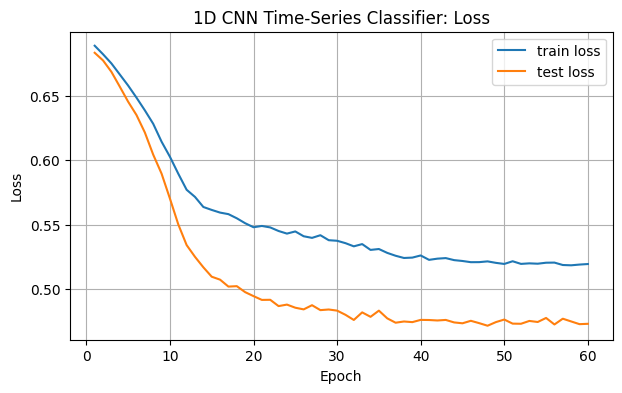

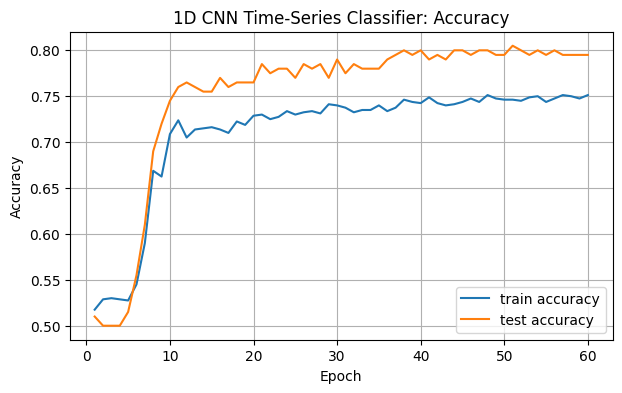

In [14]:
# =====================================================================
# 3. INITIALIZE AND TRAIN THE MODEL
# =====================================================================

bayes_model = BayesianLateFusionHeartDiseaseModel(
    sequence_length=2500, num_classes=2, in_channels=12, demog_dim=fused_demog_dim
)

ts_history = train_bayesian_classifier(
    bayes_model, ts_train_loader, ts_test_loader, epochs=60, learning_rate=1e-4, sample_nbr=3
)

plot_history(ts_history, title="1D CNN Time-Series Classifier")

In [15]:
bayes_model.eval()
X_batch, demog_batch, y_batch = next(iter(ts_test_loader))

n_samples = 50
preds = torch.stack([
    torch.softmax(bayes_model(X_batch.to(device), demog_batch.to(device)), dim=1)
    for _ in range(n_samples)
])  # [n_samples, batch, num_classes]


mean_probs = preds.mean(dim=0)   # predicted probability
std_probs  = preds.std(dim=0)    # epistemic uncertainty — how much the model disagrees with itself

predicted_class = mean_probs.argmax(dim=1)              # final prediction
confidence = mean_probs.max(dim=1).values                # P(predicted class)
uncertainty = std_probs.gather(1, predicted_class.unsqueeze(1)).squeeze(1)  # std on the predicted class


for i in range(len(y_batch)):
    print(f"Sample {i}: true={y_batch[i].item()}, pred={predicted_class[i].item()}, "
          f"confidence={confidence[i].item():.3f}, uncertainty (std)={uncertainty[i].item():.3f}")

Sample 0: true=0, pred=0, confidence=0.628, uncertainty (std)=0.021
Sample 1: true=1, pred=0, confidence=0.608, uncertainty (std)=0.023
Sample 2: true=1, pred=1, confidence=0.805, uncertainty (std)=0.025
Sample 3: true=1, pred=1, confidence=0.934, uncertainty (std)=0.009
Sample 4: true=0, pred=0, confidence=0.592, uncertainty (std)=0.017
Sample 5: true=1, pred=1, confidence=0.824, uncertainty (std)=0.016
Sample 6: true=0, pred=0, confidence=0.567, uncertainty (std)=0.015
Sample 7: true=1, pred=1, confidence=0.894, uncertainty (std)=0.016
Sample 8: true=1, pred=1, confidence=0.609, uncertainty (std)=0.032
Sample 9: true=0, pred=0, confidence=0.696, uncertainty (std)=0.011
Sample 10: true=1, pred=1, confidence=0.654, uncertainty (std)=0.023
Sample 11: true=1, pred=1, confidence=0.762, uncertainty (std)=0.013
Sample 12: true=0, pred=0, confidence=0.835, uncertainty (std)=0.008
Sample 13: true=1, pred=1, confidence=0.779, uncertainty (std)=0.013
Sample 14: true=1, pred=1, confidence=0.783,


## 15. Inspect Time-Series Predictions


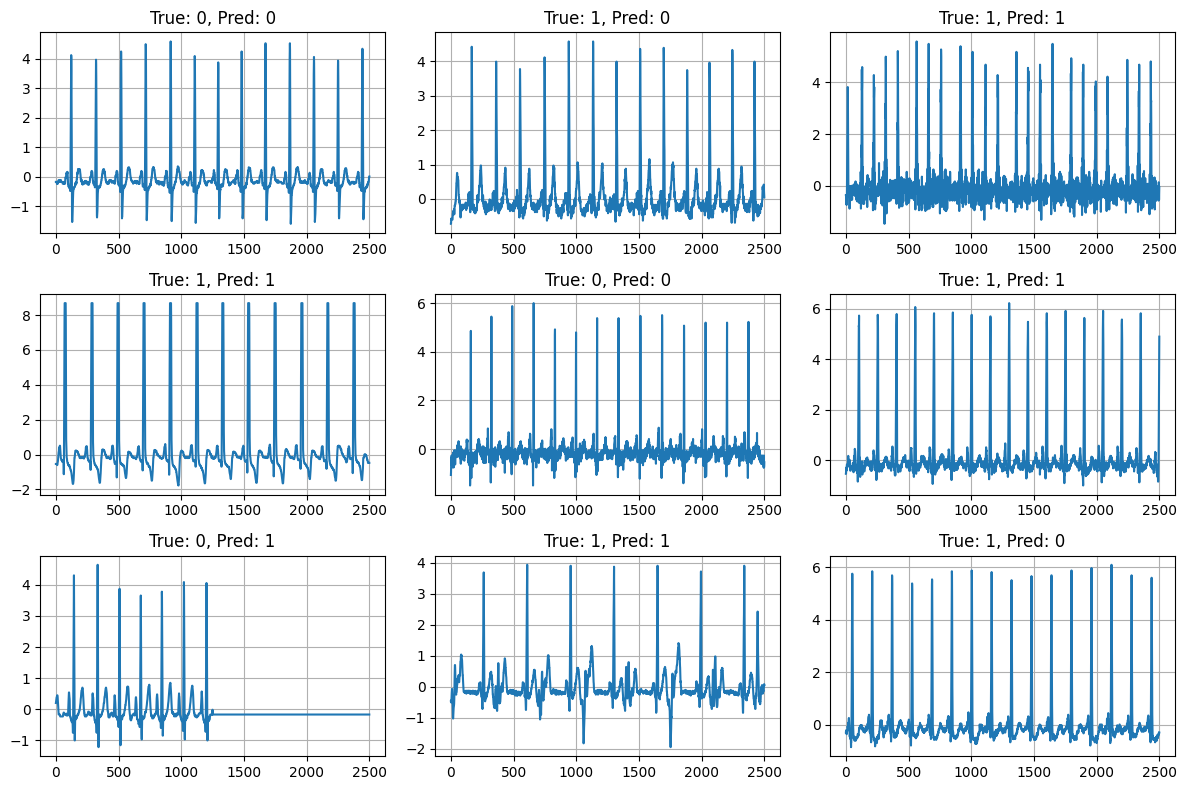

In [ ]:
bayes_model.eval()

X_batch, demog_batch, y_batch = next(iter(ts_test_loader))

with torch.no_grad():
    logits = bayes_model(X_batch.to(device), demog_batch.to(device))
    predictions = torch.argmax(logits, dim=1).cpu()

plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.plot(X_batch[i, 0].cpu().numpy())
    plt.title(f"True: {y_batch[i].item()}, Pred: {predictions[i].item()}")
    plt.grid(True)

plt.tight_layout()
plt.show()


## 16. Optional: Visualize Learned 1D Filters

The first convolutional layer learns small time-domain filters. Each filter has length 5 in this example.

These learned filters can be thought of as small pattern detectors.


In [ ]:
'''
first_conv = ts_model.features[0]
filters = first_conv.weight.detach().cpu().numpy()

plt.figure(figsize=(10, 6))
for i in range(filters.shape[0]):
    plt.subplot(2, 4, i + 1)
    plt.plot(filters[i, 0])
    plt.title(f"Filter {i}")
    plt.grid(True)

plt.tight_layout()
plt.show()
'''


'\nfirst_conv = ts_model.features[0]\nfilters = first_conv.weight.detach().cpu().numpy()\n\nplt.figure(figsize=(10, 6))\nfor i in range(filters.shape[0]):\n    plt.subplot(2, 4, i + 1)\n    plt.plot(filters[i, 0])\n    plt.title(f"Filter {i}")\n    plt.grid(True)\n\nplt.tight_layout()\nplt.show()\n'


# Summary

This notebook showed two applications of convolutional neural networks in PyTorch.

## 2D CNN for MNIST

A 2D CNN uses filters that slide across image height and width. This is useful for image data because nearby pixels contain meaningful local structure.

## 1D CNN for Time Series

A 1D CNN uses filters that slide along the time axis. This is useful for detecting short temporal patterns such as oscillations, spikes, jumps, or repeated motifs.

## Key PyTorch Ideas

The most important PyTorch components were:

- `nn.Conv2d` for image convolution,
- `nn.Conv1d` for time-series convolution,
- `nn.ReLU` for nonlinear activation,
- `nn.MaxPool2d` and `nn.MaxPool1d` for downsampling,
- `nn.Linear` for dense classification layers,
- `nn.CrossEntropyLoss` for multiclass classification,
- `loss.backward()` for automatic backpropagation,
- `torch.optim.Adam` for parameter updates.

Compared with the NumPy implementation, PyTorch makes the neural network code much shorter because it handles gradients automatically.


## Classification Metrics

## 1. Setup

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
    auc,
)

## 2. Prediction objects used by the metrics

In [17]:
def as_numpy(x):
    """Convert torch tensors or array-like objects to NumPy arrays."""
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def probs_to_predictions(probs, threshold=0.5):
    """
    Convert probabilities to hard class predictions.

    Args:
        probs: Either shape [N] containing P(class 1), or shape [N, 2]
               containing [P(class 0), P(class 1)].
        threshold: Positive-class threshold used if probs has shape [N].

    Returns:
        y_pred: shape [N]
    """
    probs = as_numpy(probs)

    if probs.ndim == 1:
        return (probs >= threshold).astype(int)

    if probs.ndim == 2:
        return np.argmax(probs, axis=1).astype(int)

    raise ValueError("probs must have shape [N] or [N, C].")


def positive_class_probability(probs):
    """
    Extract P(class 1) from either shape [N] or shape [N, 2].
    """
    probs = as_numpy(probs)

    if probs.ndim == 1:
        return probs

    if probs.ndim == 2 and probs.shape[1] == 2:
        return probs[:, 1]

    raise ValueError("For binary metrics, probs must have shape [N] or [N, 2].")

## 3. Collecting predictions from a standard neural network

In [18]:
@torch.no_grad()
def collect_predictions_bayesian_nn_blitz(model, data_loader, device, n_samples=30):
    model.eval()
    model.to(device)

    all_y_true = []
    all_probs = []

    for batch in data_loader:
        *inputs, y_batch = batch
        inputs = [x.to(device) for x in inputs]
        y_batch = y_batch.to(device)  # ensure consistent device handling

        batch_size = y_batch.size(0)
        batch_probs = torch.zeros(n_samples, batch_size, device=device)

        for i in range(n_samples):
            logits = model(*inputs)  # shape [batch, 2]
            probs = torch.softmax(logits, dim=1)[:, 1]
            batch_probs[i] = probs

        mean_probs = batch_probs.mean(dim=0)

        all_probs.append(mean_probs.cpu().numpy())
        all_y_true.append(y_batch.cpu().numpy())

    y_true = np.concatenate(all_y_true)
    probs = np.concatenate(all_probs)
    y_pred = (probs >= 0.5).astype(int)

    return y_true, probs, y_pred

## 5. Confusion matrix quantities

In [19]:
def confusion_counts(y_true, y_pred):
    """
    Return TN, FP, FN, TP for binary labels 0 and 1.
    """
    y_true = as_numpy(y_true).astype(int)
    y_pred = as_numpy(y_pred).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn, fp, fn, tp

## 6. Accuracy

In [20]:
def compute_accuracy(y_true, y_pred):
    y_true = as_numpy(y_true)
    y_pred = as_numpy(y_pred)
    return np.mean(y_true == y_pred)

## 7. Sensitivity and specificity

In [21]:
def compute_sensitivity_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_counts(y_true, y_pred)

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return sensitivity, specificity

## 8. Balanced accuracy

In [22]:
def compute_balanced_accuracy(y_true, y_pred):
    sensitivity, specificity = compute_sensitivity_specificity(y_true, y_pred)
    return 0.5 * (sensitivity + specificity)

## 9. AUROC

In [44]:
def compute_auroc(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return roc_auc_score(y_true, p1)


def plot_roc_curve(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    fpr, tpr, thresholds = roc_curve(y_true, p1)
    score = roc_auc_score(y_true, p1)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUROC = {score:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate / sensitivity")
    plt.title("ROC curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 10. AUPRC

In [43]:
def compute_auprc(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return average_precision_score(y_true, p1)


def plot_precision_recall_curve(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    precision, recall, thresholds = precision_recall_curve(y_true, p1)
    score = average_precision_score(y_true, p1)
    prevalence = np.mean(y_true == 1)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUPRC = {score:.3f}")
    plt.hlines(prevalence, 0, 1, linestyle="--", label=f"Baseline = {prevalence:.3f}")
    plt.xlabel("Recall / sensitivity")
    plt.ylabel("Precision")
    plt.title("Precision-recall curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 11. Negative log likelihood

In [25]:
def compute_negative_log_likelihood(y_true, probs, eps=1e-12):
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        p1 = np.clip(probs, eps, 1.0 - eps)
        return -np.mean(y_true * np.log(p1) + (1 - y_true) * np.log(1 - p1))

    if probs.ndim == 2:
        probs = np.clip(probs, eps, 1.0)
        probs = probs / probs.sum(axis=1, keepdims=True)
        return log_loss(y_true, probs, labels=[0, 1])

    raise ValueError("probs must have shape [N] or [N, 2].")

## 12. Brier score

In [26]:
def compute_brier_score(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)
    return np.mean((p1 - y_true) ** 2)

## 13. Expected calibration error

In [27]:
def compute_expected_calibration_error(y_true, probs, n_bins=10):
    """
    Confidence-based ECE for binary or multiclass probabilities.

    Args:
        y_true: shape [N]
        probs: shape [N, C] or shape [N] for binary P(class 1)
        n_bins: number of confidence bins

    Returns:
        ece: scalar
    """
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        probs = np.column_stack([1.0 - probs, probs])

    y_pred = probs.argmax(axis=1)
    confidence = probs.max(axis=1)
    correct = (y_pred == y_true).astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for m in range(n_bins):
        lo = bin_edges[m]
        hi = bin_edges[m + 1]

        if m == 0:
            in_bin = (confidence >= lo) & (confidence <= hi)
        else:
            in_bin = (confidence > lo) & (confidence <= hi)

        prop = np.mean(in_bin)

        if prop > 0:
            acc_bin = np.mean(correct[in_bin])
            conf_bin = np.mean(confidence[in_bin])
            ece += prop * abs(acc_bin - conf_bin)

    return ece


def calibration_table(y_true, probs, n_bins=10):
    """
    Return bin-level calibration information.
    """
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        probs = np.column_stack([1.0 - probs, probs])

    y_pred = probs.argmax(axis=1)
    confidence = probs.max(axis=1)
    correct = (y_pred == y_true).astype(float)

    rows = []
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    for m in range(n_bins):
        lo = bin_edges[m]
        hi = bin_edges[m + 1]

        if m == 0:
            in_bin = (confidence >= lo) & (confidence <= hi)
        else:
            in_bin = (confidence > lo) & (confidence <= hi)

        n_bin = int(np.sum(in_bin))

        if n_bin > 0:
            rows.append({
                "bin": m + 1,
                "confidence_lower": lo,
                "confidence_upper": hi,
                "n": n_bin,
                "mean_confidence": float(np.mean(confidence[in_bin])),
                "empirical_accuracy": float(np.mean(correct[in_bin])),
                "abs_gap": float(abs(np.mean(correct[in_bin]) - np.mean(confidence[in_bin]))),
            })
        else:
            rows.append({
                "bin": m + 1,
                "confidence_lower": lo,
                "confidence_upper": hi,
                "n": 0,
                "mean_confidence": np.nan,
                "empirical_accuracy": np.nan,
                "abs_gap": np.nan,
            })

    return pd.DataFrame(rows)


def plot_calibration_curve(y_true, probs, n_bins=10):
    table = calibration_table(y_true, probs, n_bins=n_bins)
    table_nonempty = table.dropna(subset=["mean_confidence", "empirical_accuracy"])

    plt.figure(figsize=(6, 5))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.scatter(
        table_nonempty["mean_confidence"],
        table_nonempty["empirical_accuracy"],
        s=50,
        label="Observed bins",
    )
    plt.xlabel("Mean confidence")
    plt.ylabel("Empirical accuracy")
    plt.title("Calibration curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 14. Negative ELBO

In [28]:
def estimate_negative_elbo_per_example_pyro(model, guide, data_loader, device, dataset_size=None):
    """
    Estimate negative ELBO per example for a Pyro Bayesian neural network.

    Args:
        model: Pyro model with forward(x, y=None, dataset_size=None).
        guide: Pyro guide.
        data_loader: DataLoader yielding (x, y).
        device: torch device.
        dataset_size: Optional size used for minibatch scaling. If None, each batch
                      uses its own batch size, which is often appropriate for a
                      held-out evaluation estimate.

    Returns:
        negative_elbo_per_example: scalar float
    """
    try:
        import pyro
        from pyro.infer import Trace_ELBO
    except ImportError as exc:
        raise ImportError("This function requires Pyro. Install pyro-ppl first.") from exc

    model.eval()
    elbo = Trace_ELBO()

    total_loss = 0.0
    total_examples = 0

    for x, y in data_loader:
        x = x.to(device)
        y = y.to(device)
        batch_size = x.shape[0]
        ds = dataset_size if dataset_size is not None else batch_size

        loss = elbo.differentiable_loss(model, guide, x, y, ds)

        total_loss += float(loss.detach().cpu())
        total_examples += batch_size

    return total_loss / max(total_examples, 1)


def estimate_cross_entropy_per_example_standard_nn(model, data_loader, device):
    """
    Estimate cross-entropy/NLL per example for a standard neural network.
    This is the standard deterministic analogue of the likelihood part of ELBO.
    """
    model.eval()

    total_loss = 0.0
    total_examples = 0

    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            loss = F.cross_entropy(logits, y, reduction="sum")
            total_loss += float(loss.detach().cpu())
            total_examples += x.shape[0]

    return total_loss / max(total_examples, 1)

## 15. One function to calculate all non-ELBO metrics

In [29]:
def calculate_binary_classification_metrics(y_true, probs, threshold=0.5, n_bins=10):
    """
    Calculate binary classification metrics from labels and probabilities.

    Args:
        y_true: shape [N], labels 0/1.
        probs: shape [N] containing P(class 1), or shape [N, 2].
        threshold: threshold for P(class 1), used only if probs has shape [N].
        n_bins: number of bins for ECE.

    Returns:
        metrics: dictionary
    """
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        y_pred = probs_to_predictions(probs, threshold=threshold)
        p1 = probs
        probs_2d = np.column_stack([1.0 - p1, p1])
    else:
        y_pred = probs.argmax(axis=1)
        p1 = probs[:, 1]
        probs_2d = probs

    tn, fp, fn, tp = confusion_counts(y_true, y_pred)
    sensitivity, specificity = compute_sensitivity_specificity(y_true, y_pred)

    metrics = {
        "accuracy": compute_accuracy(y_true, y_pred),
        "balanced_accuracy": compute_balanced_accuracy(y_true, y_pred),
        "auroc": compute_auroc(y_true, probs_2d),
        "auprc": compute_auprc(y_true, probs_2d),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "negative_log_likelihood": compute_negative_log_likelihood(y_true, probs_2d),
        "brier_score": compute_brier_score(y_true, probs_2d),
        "expected_calibration_error": compute_expected_calibration_error(y_true, probs_2d, n_bins=n_bins),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "positive_prevalence": float(np.mean(y_true == 1)),
    }

    return metrics

## 16. Wrapper for a standard neural network classifier (use later)

In [30]:
def evaluate_bayesian_nn_classifier(model, guide, data_loader, device, num_samples=100, n_bins=10, dataset_size=None):
    y_true, probs, y_pred = collect_predictions_bayesian_nn(
        model=model,
        guide=guide,
        data_loader=data_loader,
        device=device,
        num_samples=num_samples,
    )

    metrics = calculate_binary_classification_metrics(
        y_true=y_true,
        probs=probs,
        n_bins=n_bins,
    )

    metrics["negative_elbo_per_example"] = estimate_negative_elbo_per_example_pyro(
        model=model,
        guide=guide,
        data_loader=data_loader,
        device=device,
        dataset_size=dataset_size,
    )

    metrics["num_posterior_prediction_samples"] = num_samples

    return metrics, y_true, probs, y_pred

## 18. Demonstration with synthetic predictions

In [31]:
y_true_test, probs, y_pred = collect_predictions_bayesian_nn_blitz(
    model=bayes_model,
    data_loader=ts_test_loader,
    device=device,
    n_samples=100,
)

metrics_demo = calculate_binary_classification_metrics(
    y_true=y_true_test,
    probs=probs,
    n_bins=10,
)

pd.DataFrame([metrics_demo]).T.rename(columns={0: "value"})

,value
accuracy,0.800000
balanced_accuracy,0.800000
auroc,0.872100
auprc,0.868622
sensitivity,0.750000
specificity,0.850000
negative_log_likelihood,0.474757
brier_score,0.151152
expected_calibration_error,0.079745
tn,85.000000


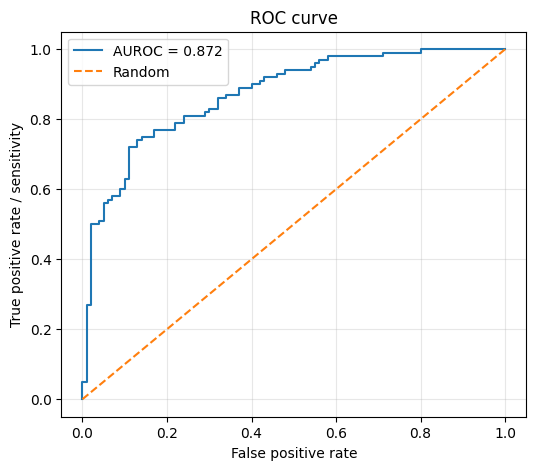

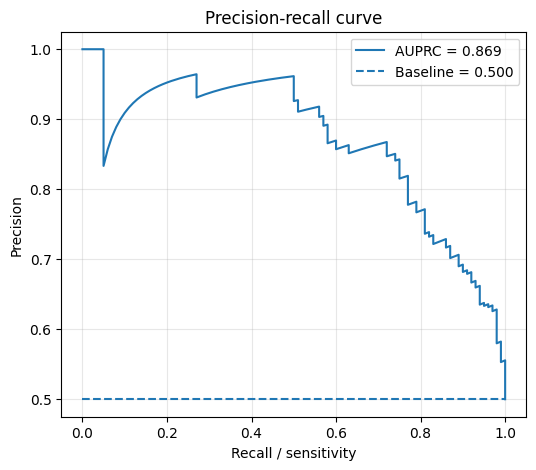

array([0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 0])
[0.37276337 0.39088514 0.80569774 0.93587554 0.4080841  0.8238949
 0.43409404 0.89419615 0.60393256 0.30315417 0.65602475 0.76206046
 0.16467251 0.7801462  0.7832542  0.20629668 0.48147833 0.46780118
 0.47235802 0.3994897  0.432135   0.68033487 0.7538861  0.70177656
 0.17178707 0.26799902 0.410157   0.98838466 0.40032238 0.5618

In [45]:
plot_roc_curve(y_true_test, probs)
plot_precision_recall_curve(y_true_test, probs)

print(repr(y_true_test))
print(probs)

In [49]:
from pathlib import Path
from datetime import datetime
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve
from sklearn.calibration import calibration_curve

# ==================================================
# 1. SAVE DIRECTORY SETUP
# ==================================================
run_name = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = Path(f"/content/drive/MyDrive/REU ECG Analysis/BCNN/{run_name}")
save_dir.mkdir(parents=True, exist_ok=True)

plots_dir = save_dir / "plots"
plots_dir.mkdir(exist_ok=True)

# ==================================================
# 2. SAVE MODEL + DATA
# ==================================================
torch.save(bayes_model.state_dict(), save_dir / "model_weights.pth")
torch.save(bayes_model, save_dir / "full_model.pt")

pd.DataFrame([metrics_demo]).to_csv(save_dir / "metrics.csv", index=False)

cm = confusion_matrix(y_true_test, y_pred)

pd.DataFrame(
cm,
index=["True Neg", "True Pos"],
columns=["Pred Neg", "Pred Pos"]
).to_csv(save_dir / "confusion_matrix.csv")

pd.DataFrame({
"y_true": y_true_test,
"y_pred": y_pred,
"p_positive": probs
}).to_csv(save_dir / "predictions.csv", index=False)

# ==================================================
# 3. SAFE FIGURE SAVER
# ==================================================
def save_fig(fig, name):
  fig.savefig(plots_dir / name, bbox_inches="tight", dpi=300)
  plt.close(fig)

# ==================================================
# 4. PLOTTING FUNCTIONS (RETURN FIGURES — CRITICAL FIX)
# ==================================================

def plot_roc_curve(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    fpr, tpr, thresholds = roc_curve(y_true, p1)
    score = roc_auc_score(y_true, p1)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, label=f"AUROC = {score:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--", label="Random")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate / sensitivity")
    ax.set_title("ROC curve")
    ax.legend()
    ax.grid(True, alpha=0.3)
    return fig


def plot_precision_recall_curve(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    precision, recall, thresholds = precision_recall_curve(y_true, p1)
    score = average_precision_score(y_true, p1)
    prevalence = np.mean(y_true == 1)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(recall, precision, label=f"AUPRC = {score:.3f}")
    ax.hlines(prevalence, 0, 1, linestyle="--", label=f"Baseline = {prevalence:.3f}")
    ax.set_xlabel("Recall / sensitivity")
    ax.set_ylabel("Precision")
    ax.set_title("Precision-recall curve")
    ax.legend()
    ax.grid(True, alpha=0.3)
    return fig


def plot_calibration_curve(y_true, probs, n_bins=10):
  fig, ax = plt.subplots()
  prob_true, prob_pred = calibration_curve(y_true, probs, n_bins=n_bins)
  ax.plot(prob_pred, prob_true, marker="o")
  ax.set_title("Calibration Curve")
  return fig


def plot_history(history, title="Training History"):
  epochs = np.arange(1, len(history["train_loss"]) + 1)

  fig1, ax1 = plt.subplots(figsize=(7, 4))

  ax1.plot(epochs, history["train_loss"], label="train loss")

  if "test_loss" in history and len(history["test_loss"]) > 0:
    ax1.plot(epochs, history["test_loss"], label="test loss")

  ax1.set_xlabel("Epoch")
  ax1.set_ylabel("Loss")
  ax1.set_title(title + ": Loss")
  ax1.grid(True)
  ax1.legend()

  fig2, ax2 = plt.subplots(figsize=(7, 4))

  ax2.plot(epochs, history["train_acc"], label="train accuracy")

  if "test_acc" in history and len(history["test_acc"]) > 0:
    ax2.plot(epochs, history["test_acc"], label="test accuracy")

  ax2.set_xlabel("Epoch")
  ax2.set_ylabel("Accuracy")
  ax2.set_title(title + ": Accuracy")
  ax2.grid(True)
  ax2.legend()

  return fig1, fig2

# ==================================================
# 5. SAVE ALL PLOTS (NOW GUARANTEED NON-BLANK)
# ==================================================

fig = plot_roc_curve(y_true_test, probs)
save_fig(fig, "roc_curve.png")

fig = plot_precision_recall_curve(y_true_test, probs)
save_fig(fig, "precision_recall_curve.png")

fig = plot_calibration_curve(y_true_test, probs, n_bins=10)
save_fig(fig, "calibration_curve.png")

fig1, fig2 = plot_history(ts_history, title="1D CNN Time-Series Classifier")

save_fig(fig1, "history_loss.png")
save_fig(fig2, "history_accuracy.png")

# ==================================================
# 6. EXTRA TABLE (CALIBRATION)
# ==================================================
calibration_table(y_true_test, probs, n_bins=10).to_csv(
save_dir / "calibration_table.csv",
index=False
)

# ==================================================
# 7. DONE
# ==================================================
print(f"Saved experiment to {save_dir}")

Saved experiment to /content/drive/MyDrive/REU ECG Analysis/BCNN/20260707_150119


In [32]:
apple = 1
print(apple)

1


Confusion matrix [[TN, FP], [FN, TP]]:
[[77 23]
 [27 73]]


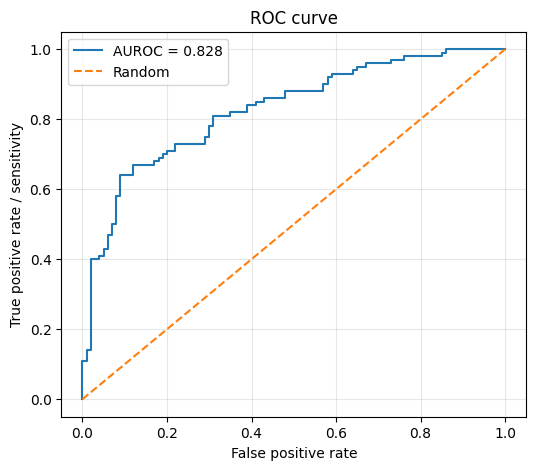

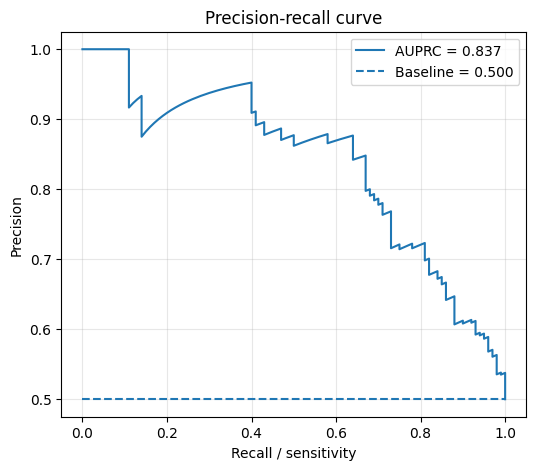

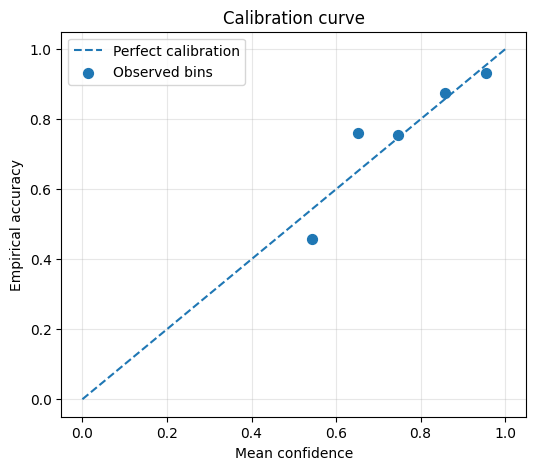

,bin,confidence_lower,confidence_upper,n,mean_confidence,empirical_accuracy,abs_gap
0,1,0.0,0.1,0,NaN,NaN,NaN
1,2,0.1,0.2,0,NaN,NaN,NaN
2,3,0.2,0.3,0,NaN,NaN,NaN
3,4,0.3,0.4,0,NaN,NaN,NaN
4,5,0.4,0.5,0,NaN,NaN,NaN
5,6,0.5,0.6,35,0.543001,0.457143,0.085858
6,7,0.6,0.7,50,0.651739,0.760000,0.108261
7,8,0.7,0.8,53,0.747615,0.754717,0.007102
8,9,0.8,0.9,32,0.858272,0.875000,0.016728
9,10,0.9,1.0,30,0.954358,0.933333,0.021024


In [ ]:

print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_true_test, y_pred, labels=[0, 1]))

plot_roc_curve(y_true_test, probs)
plot_precision_recall_curve(y_true_test, probs)
plot_calibration_curve(y_true_test, probs, n_bins=10)
calibration_table(y_true_test, probs, n_bins=10)


## 19. How to use this with your ECG standard neural network

If you have a standard PyTorch CNN called `standard_cnn`, use:

```python
standard_metrics, standard_y, standard_probs, standard_pred = evaluate_standard_nn_classifier(
    model=standard_cnn,
    data_loader=ts_test_loader,
    device=device,
    n_bins=10,
)

pd.DataFrame([standard_metrics], index=["standard CNN"])
```

The model must return logits of shape `[batch_size, 2]`.

## 20. How to use this with your ECG Bayesian neural network

If you have a Bayesian CNN called `bcnn` and guide called `bcnn_guide`, use:

```python
bayes_metrics, bayes_y, bayes_probs, bayes_pred = evaluate_bayesian_nn_classifier(
    model=bcnn,
    guide=bcnn_guide,
    data_loader=ts_test_loader,
    device=device,
    num_samples=100,
    n_bins=10,
    dataset_size=None,
)

pd.DataFrame([bayes_metrics], index=["Bayesian CNN"])
```

For training ELBO during minibatch training, `dataset_size` should usually be the full training-set size:

```python
train_dataset_size = len(ts_train_loader.dataset)
```

For held-out test-set reporting, using `dataset_size=None` gives an evaluation-style per-example estimate on the batches being evaluated.

## 21. Comparing a standard classifier and Bayesian classifier

Once both models have been evaluated, compare them side-by-side:

```python
comparison = pd.DataFrame(
    [standard_metrics, bayes_metrics],
    index=["standard CNN", "Bayesian CNN"],
)

comparison.T
```

Interpretation guidance:

| Metric | Better direction | What it emphasizes |
|---|---:|---|
| negative ELBO | lower | Bayesian posterior fit plus prior regularization |
| accuracy | higher | Overall hard-decision correctness |
| balanced accuracy | higher | Average performance across positive and negative classes |
| AUROC | higher | Ranking positives above negatives |
| AUPRC | higher | Positive-class retrieval, especially with imbalance |
| sensitivity | higher | Avoiding false negatives |
| specificity | higher | Avoiding false positives |
| negative log likelihood | lower | Probabilistic correctness; punishes confident errors |
| Brier score | lower | Mean squared probability error |
| expected calibration error | lower | Agreement between confidence and empirical accuracy |

For a medical classifier, raw accuracy is rarely enough. A Bayesian classifier may have similar accuracy to a standard classifier but better NLL, Brier score, ECE, or uncertainty behavior. That can still be valuable if uncertainty is clinically important.

## 22. Practical notes for Bayesian classifiers

### Use enough posterior samples

Bayesian predictions can be noisy if `num_samples` is small. For final evaluation, try values such as:

```python
num_samples = 100
num_samples = 250
num_samples = 500
```

and check whether the metrics stabilize.

### Calculate metrics from averaged probabilities

For Bayesian classifiers, do not calculate metrics from a single sampled network unless you specifically want to analyze one posterior draw. Usually, use:

$$
\bar p_i = \frac{1}{S}\sum_{s=1}^S p(y_i=1 \mid x_i, \theta^{(s)}).
$$

Then calculate accuracy, AUROC, AUPRC, NLL, Brier score, and ECE from \(\bar p_i\).

### Do not expect ELBO and accuracy to move identically

Negative ELBO optimizes probabilistic fit plus a KL penalty. Accuracy is a thresholded hard-decision metric. They are related but not equivalent.

### Report class prevalence

AUPRC and accuracy are easier to interpret when you also report:

$$
P(y=1).
$$

This notebook includes `positive_prevalence` in the metrics dictionary.